# КИМ 1.1. Нейрон и перцептрон — эталонное решение

> **Это эталонное решение** для преподавателя. Студентам выдаётся ноутбук-задание
> [`kim-01-neuron-perceptron.ipynb`](./kim-01-neuron-perceptron.ipynb) без заполненных ячеек.
>
> Код ниже — один из возможных вариантов решения; не единственный и не обязательно
> оптимальный. Приводится для сверки и подготовки к защите.

В этом эталоне:
- **Часть А** — реализация нейрона на чистом NumPy (педагогический стержень: увидеть
  матричную природу прямого прохода).
- **Часть Б** — перцептрон на **PyTorch** (в задании допускается Keras или PyTorch;
  здесь приводится PyTorch-версия).

---
## Часть А. Нейрон на чистом NumPy

### 0. Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

### 1. Прямой проход одного нейрона

In [2]:
def neuron_forward(x, w, b, activation):
    z = np.dot(w, x) + b
    return activation(z)

### 2. Функции активации

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0.0, z)

### 3. Сравнение функций активации

sigmoid: 0.21840253609763446
tanh:    -0.8551470292769645
relu:    0.0


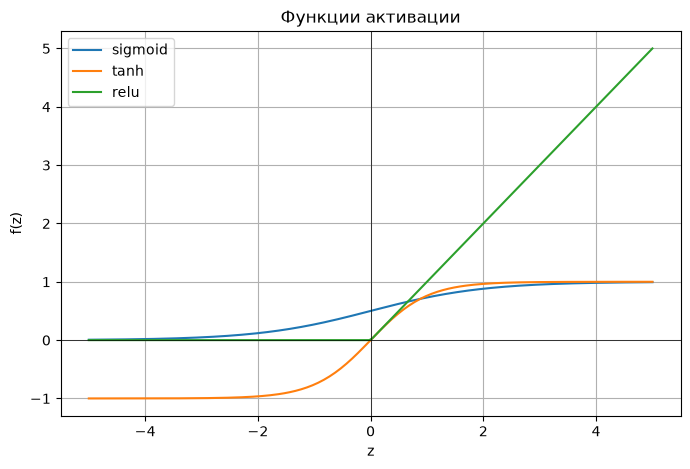

In [4]:
x_test = np.array([1.0, 2.0, -1.0, 0.5])
w_test = np.array([0.5, -0.5, 1.0, 0.25])
b_test = 0.1

print('sigmoid:', neuron_forward(x_test, w_test, b_test, sigmoid))
print('tanh:   ', neuron_forward(x_test, w_test, b_test, tanh))
print('relu:   ', neuron_forward(x_test, w_test, b_test, relu))

z = np.linspace(-5, 5, 200)
plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid(z), label='sigmoid')
plt.plot(z, tanh(z), label='tanh')
plt.plot(z, relu(z), label='relu')
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.xlabel('z'); plt.ylabel('f(z)'); plt.title('Функции активации')
plt.legend(); plt.grid(True); plt.show()

**Ответ:** `sigmoid` насыщается (производная → 0) при $|z| \gtrsim 4$, где
$\sigma(z) \to 0$ или $1$. Это проблематично, потому что при насыщении градиент
обнуляется и обучение через backprop замедляется или останавливается (проблема
затухающего градиента). `relu` не насыщается в положительной области
($f'(z) = 1$ при $z > 0$), поэтому градиент течёт свободно — основной повод
предпочесть `relu` в скрытых слоях.

---
## Часть Б. Перцептрон на PyTorch (Fashion-MNIST)

### 4. Импорт PyTorch и выбор устройства

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print('Устройство:', device)
torch.manual_seed(42)

Устройство: cuda


### 5. Загрузка Fashion-MNIST через torchvision

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),                # в [0, 1], форма (1, 28, 28)
    transforms.Lambda(lambda x: x.view(-1))  # вытянуть в (784,)
])

train_data = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=200, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=500, shuffle=False)

class_names = ['Футболка', 'Брюки', 'Свитер', 'Платье', 'Пальто',
               'Сандали', 'Рубашка', 'Кроссовки', 'Сумка', 'Ботильоны']
print('Train:', len(train_data), 'Test:', len(test_data))

Train: 60000 Test: 10000


### 6. Архитектура перцептрона

In [7]:
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 800),
            nn.ReLU(),
            nn.Linear(800, 10),
            # Softmax не нужен — он встроен в CrossEntropyLoss
        )

    def forward(self, x):
        return self.net(x)

model = Perceptron().to(device)
print(model)
print('Параметров:', sum(p.numel() for p in model.parameters()))

Perceptron(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=800, bias=True)
    (1): ReLU()
    (2): Linear(in_features=800, out_features=10, bias=True)
  )
)


Параметров: 636010


**Замечание:** в PyTorch `nn.CrossEntropyLoss` уже включает softmax, поэтому
`Softmax` в конце модели ставить **не нужно** — иначе функция потерь применит его
дважды. Это отличие от Keras, где softmax должен быть в модели явно.

### 7. Loss и оптимизатор

In [8]:
criterion = nn.CrossEntropyLoss()   # принимает raw logits + индексы классов
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### 8. Цикл обучения

In [9]:
def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)              # прямой проход
        loss = criterion(logits, y)    # вычисление потерь
        loss.backward()                # backprop (автоматический!)
        optimizer.step()               # обновление весов
        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return running_loss / total, correct / total

for epoch in range(10):
    loss, acc = train(model, train_loader, criterion, optimizer, device)
    print(f'Эпоха {epoch+1:2d}: loss={loss:.4f}  acc={acc:.4f}')

Эпоха  1: loss=0.5438  acc=0.8118


Эпоха  2: loss=0.3883  acc=0.8629


Эпоха  3: loss=0.3479  acc=0.8758


Эпоха  4: loss=0.3180  acc=0.8858


Эпоха  5: loss=0.2967  acc=0.8910


Эпоха  6: loss=0.2791  acc=0.8970


Эпоха  7: loss=0.2625  acc=0.9037


Эпоха  8: loss=0.2528  acc=0.9075


Эпоха  9: loss=0.2431  acc=0.9102


Эпоха 10: loss=0.2331  acc=0.9145


### 9. Оценка на тесте

In [10]:
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

test_acc = evaluate(model, test_loader, device)
print(f'\nТестовая точность: {test_acc:.4f}')  # ожидается ~0.88


Тестовая точность: 0.8851


### 10. Визуализация предсказаний

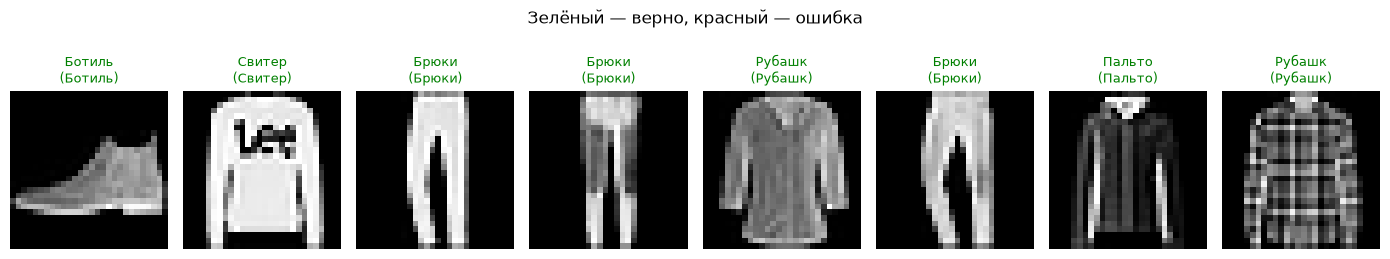

In [11]:
# Возьмём 8 тестовых изображений
model.eval()
x_batch, y_batch = next(iter(test_loader))
with torch.no_grad():
    logits = model(x_batch.to(device)).cpu()
    preds = logits.argmax(1)

n = 8
plt.figure(figsize=(14, 3))
for i in range(n):
    plt.subplot(1, n, i + 1)
    plt.imshow(x_batch[i].view(28, 28), cmap='gray')
    pred, true = preds[i].item(), y_batch[i].item()
    color = 'green' if pred == true else 'red'
    plt.title(f'{class_names[pred][:6]}\n({class_names[true][:6]})', color=color, fontsize=9)
    plt.axis('off')
plt.suptitle('Зелёный — верно, красный — ошибка'); plt.tight_layout(); plt.show()

---
**Параметры сети `Linear(784, 800) → Linear(800, 10)`:** 784·800 + 800 = 628 000 на
скрытом слое; 800·10 + 10 = 8 010 на выходном — всего ~636 000 обучаемых параметров.

**Ключевые этапы цикла обучения PyTorch (для защиты):**
1. `optimizer.zero_grad()` — обнулить накопленные градиенты (PyTorch их суммирует!).
2. `logits = model(x)` — прямой проход.
3. `loss = criterion(logits, y)` — вычислить функцию потерь.
4. `loss.backward()` — **обратное распространение ошибки** (автодифференцирование).
5. `optimizer.step()` — обновить веса по вычисленным градиентам.